# ID5059: Flight Delays
Investigating flight delays from several airports near New York over the course of one year. Fit at least two machine learning models and prepare a summary report for the Director of Operations of a major airport. Further information on the attributes of the nycflights13 dataset can be found [here](https://openflights.org/data.php).

**Research Questions:**
1. Can we predict, before a flight has departed, whether it will arrive late?
2. Which factors are most correlated with delays?

In [1]:
# Importing the required dependencies
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Creating the Test Set
Since we're working with supervised data, it would be sensible to have an even split of delays across the test and training sets. We can use arr_delay in flights.csv to create a classification label for delayed flights, combine the new flights.csv data with important-looking data from other .csv files, and then perform a train/test split before data exploration & wrangling.

1. Create a label is_delayed to classify whether a particular observation (row in flights.csv) is delayed or not
    * Are there any NA values for arr_delay? If so, what does that mean?
    * Decide whether to replace NA values or remove them
2. Check the distribution of delayed flights
3. Create analytical base table (ABT) with chosen high-level data
    * Is there any CSV data which is less useful?
4. Choose and perform test/train split
5. Verify that the % of delays in the training set matches the % of the delays in the test set

### 1. Create new classifier is_delayed

Work on a copy of the data for reproducibility.

In [595]:
# Locate the file, read it in, and observe
flights_file_name = "../data/flights.csv"
flights_data = pd.read_csv(flights_file_name)
flights_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00


In [596]:
# Check observations (shape[0]) and features (shape[1])
flights_data.shape

(336776, 19)

In [597]:
# Check for NA values
flights_data.isna().sum()

# 9430/336776 = 2.8% of the data is missing for arr_delay
# We will drop these rows since it's small enough to drop without losing too much info


year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

In [598]:
# Drop the rows where arr_delay is NA since we can't create a label from this
flights_clean = flights_data.dropna(subset=['arr_delay']).copy()
flights_delay_not_null = flights_data['arr_delay'].notnull().sum()

# Sanity check all rows with NA arr_delay have been dropped
if flights_delay_not_null == flights_clean.shape[0]:
    print(f"Rows before drop: {flights_data.shape[0]}")
    print(f"Rows dropped: {flights_data.isna().sum()['arr_delay']}")
    print(f"Rows remaining: {flights_clean.shape[0]}")

Rows before drop: 336776
Rows dropped: 9430
Rows remaining: 327346


In [599]:
# Create a binary classification label: 1 if flight is delayed (arr_delay >= 15), 0 otherwise
flights_clean['is_delayed'] = (flights_clean['arr_delay'] >= 15).astype(int)

# Sanity check is_delayed is categorising correctly
flights_clean[['arr_delay', 'is_delayed']].head(10)

,arr_delay,is_delayed
0,11.0,0
1,20.0,1
2,33.0,1
3,-18.0,0
4,-25.0,0
5,12.0,0
6,19.0,1
7,-14.0,0
8,-8.0,0
9,8.0,0


### 2. Check the distribution of delayed flights

If the dataset is imbalanced (eg 20% delays and 80% on-time) we will need to do a stratified split to ensure the train and test sets have similar proportions of delayed/on-time data.

In [600]:
# Check the proportion of delayed flights
print(flights_clean['is_delayed'].value_counts(normalize=True))

# The dataset is imbalanced (~25% flights are delayed) so we should use stratified splitting
# to ensure the proportion of delayed flights in the train / test sets are similar

is_delayed
0    0.755305
1    0.244695
Name: proportion, dtype: float64


### 3. Create ABT with chosen high-level data

Common causes of aviation delays may be the schedule (time of flight or month), the operator (airline or origin airport), or the environment (weather conditions or distance).

After inspecting the .csv files, airports.csv and planes.csv seem like they would have low additional value versus the expense of including them in the ABT. Planes could be used to see if there's a relationship between older plane machinery and flight delays, but this is not as obvious as the aforementioned assumptions (schedule, operator, and weather).

Therefore, we will use:
- **airlines.csv:** for airline name (instead of airline code which may be hard to read)
- **flights.csv:** for month, scheduled departure time, and origin airport
- **weather.csv:** for wind speed and visibility

This narrows the scope of the data and will simplify the model, but it may cause the final model to be oblivious of some potential causes of delays. Given the scope of this project, I've decided dropping these tables allows for deeper exploration of data which I assume is more likely to be important. If I had more time I may explore geographical data (eg northbound vs southbound delays) or plane age data. 

In [601]:
# We need to merge all of flights.csv with airlines (for names) and weather (for weather info)

# Locate the weather file, read it in, and observe
weather_file_name = "../data/weather.csv"
weather_data = pd.read_csv(weather_file_name)
weather_data.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [602]:
# Check the features in more detail to identify potential features to merge with flights.csv
weather_data.info()

# Origin, year, month, day, and hour have no null entries (could be primary key)

<class 'pandas.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  str    
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  str    
dtypes: float64(9), int64(4), str(2)
memory usage: 3.0 MB


In [603]:
# Check if the combination of origin, year, month, day, and hour is unique in weather.csv
is_unique = weather_data.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# It's not, so identify all rows that have a duplicate combination of our keys
keys = ['origin', 'year', 'month', 'day', 'hour']
duplicates = weather_data[weather_data.duplicated(subset=keys, keep=False)]

print(f"Number of duplicate rows: {duplicates.shape[0]} / {weather_data.shape[0]}")

# Sort them so the duplicates are next to each other
duplicates.sort_values(by=keys).head(10)

# Twice a year there are two entries for each airport at the same hour on the same day
# We will assume this is due to clocks going forward / back for daylight savings time

Is the keyset unique: False
Number of duplicate rows: 6 / 26115


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
7318,EWR,2013,11,3,1,51.98,39.02,61.15,310.0,6.90468,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
7319,EWR,2013,11,3,1,50.00,39.02,65.80,290.0,5.75390,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
16023,JFK,2013,11,3,1,53.96,37.94,54.51,320.0,9.20624,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
16024,JFK,2013,11,3,1,51.98,37.94,58.62,310.0,6.90468,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
24729,LGA,2013,11,3,1,55.04,39.02,54.67,330.0,9.20624,NaN,0.0,1009.3,10.0,2013-11-03T05:00:00Z
24730,LGA,2013,11,3,1,53.96,39.92,58.89,310.0,8.05546,NaN,0.0,1010.2,10.0,2013-11-03T06:00:00Z


In [604]:
# Both entries have weather info for the same time so we will calculate a simple mean of numeric values
weather_data_unique = weather_data.groupby(keys).mean(numeric_only=True).reset_index()

# Verify after taking the mean that the keyset is now unique
is_unique = weather_data_unique.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# Sanity check the new dataframe looks as expected
weather_data_unique.head(10)

Is the keyset unique: True


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
5,EWR,2013,1,1,6,37.94,28.04,67.21,240.0,11.50780,NaN,0.0,1012.4,10.0
6,EWR,2013,1,1,7,39.02,28.04,64.43,240.0,14.96014,NaN,0.0,1012.2,10.0
7,EWR,2013,1,1,8,39.92,28.04,62.21,250.0,10.35702,NaN,0.0,1012.2,10.0
8,EWR,2013,1,1,9,39.92,28.04,62.21,260.0,14.96014,NaN,0.0,1012.7,10.0
9,EWR,2013,1,1,10,41.00,28.04,59.65,260.0,13.80936,NaN,0.0,1012.4,10.0


In [605]:
# Check the features in more detail to be sure
weather_data_unique.info()

# Number of rows has reduced from 26115 to 26112 after removing duplicates (3 pairs merged)
# So this is as expected

<class 'pandas.DataFrame'>
RangeIndex: 26112 entries, 0 to 26111
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26112 non-null  str    
 1   year        26112 non-null  int64  
 2   month       26112 non-null  int64  
 3   day         26112 non-null  int64  
 4   hour        26112 non-null  int64  
 5   temp        26111 non-null  float64
 6   dewp        26111 non-null  float64
 7   humid       26111 non-null  float64
 8   wind_dir    25652 non-null  float64
 9   wind_speed  26108 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26112 non-null  float64
 12  pressure    23383 non-null  float64
 13  visib       26112 non-null  float64
dtypes: float64(9), int64(4), str(1)
memory usage: 2.8 MB


In [606]:
# Perform a left join using the chosen keys, keep all flight info but adding new weather info
flights_weather = flights_clean.merge(weather_data_unique, on=keys, how='left')

# Sanity check the merge worked as expected
flights_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

In [607]:
# Check if carrier is null in flights_weather before joining
flights_weather['carrier'].isna().sum()

np.int64(0)

In [608]:
# Locate the airlines file, read it in, and observe
airlines_file_name = "../data/airlines.csv"
airlines_data = pd.read_csv(airlines_file_name)
airlines_data.head(20)

# Airlines.csv is a complete list of all carriers and their names

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


In [609]:
# Perform a left join on carrier to add airline names instead of just codes for readability of analysis
flights_weather_airlines = flights_weather.merge(airlines_data, on='carrier', how='left')

# (Briefly) Sanity check the merged dataframe is what we expect before doing any splitting
flights_weather_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

### 4. Perform train / test split

Bin the arr_delay (currently a numerical) into categories to ensure the train and test set get an equal share of on time, slightly late and majorly late flights

<Axes: xlabel='arr_delay', ylabel='count'>

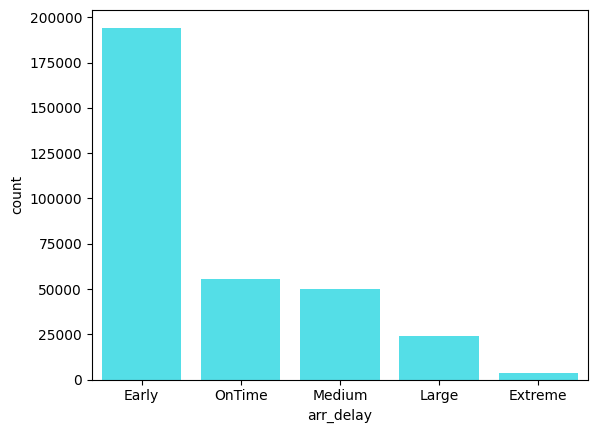

In [610]:
# Create the bins to split arr_delay into categories for stratificatoin
strat_bins = pd.cut(
    flights_weather_airlines['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

# View the distribution of the bins
sns.countplot(x=strat_bins, color='#3cf3ff')

# This confirms the distribution is imbalanced so stratified sampling would be beneficial

In [611]:
# Define how to split the data
shuffled_data = StratifiedShuffleSplit(
    n_splits=1, # We are only splitting once for a train & test set
    test_size=0.2, # Test set will be 20% of the data
    random_state=42 # Set seed to maintain split and reproducibility (Geron always uses 42)
)

# Create indexes based on the 5 bins
[(train_index, test_index)] = shuffled_data.split(
    flights_weather_airlines,
    strat_bins
)

# Create the train and test sets using the indexes
# Using a copy to keep them independent
flights_train = flights_weather_airlines.iloc[train_index].copy()
flights_test = flights_weather_airlines.iloc[test_index].copy()

### 5. Verify that the Training & Test Set have similar delay distributions

  delay_category     train      test
0          Early  0.593689  0.593692
1         OnTime  0.169160  0.169161
2         Medium  0.152259  0.152253
3          Large  0.073153  0.073148
4        Extreme  0.011738  0.011746


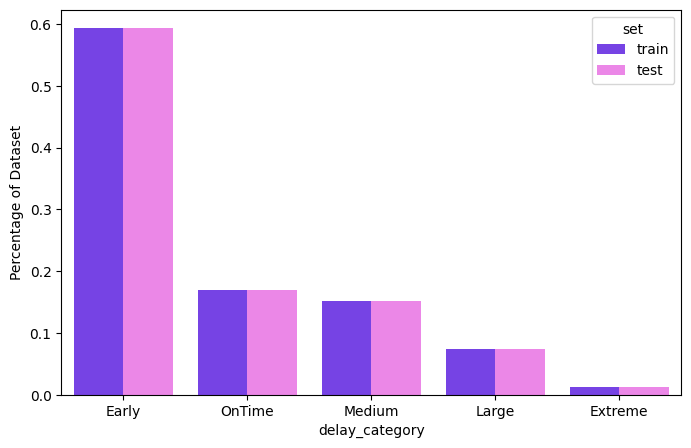

In [612]:
# Get the pre-calculated proportions using the indexes
train_dist = strat_bins.iloc[train_index].value_counts(normalize=True)
test_dist = strat_bins.iloc[test_index].value_counts(normalize=True)

# Combine and reset index in one go
dist_df = pd.DataFrame({'train': train_dist, 'test': test_dist}).reset_index()
dist_df.columns = ['delay_category', 'train', 'test']

# Check the distribution numbers
print(dist_df)

# Plot for easy viewing of train / test set distribution comparison
dist_melted = dist_df.melt(id_vars='delay_category', var_name='set', value_name='percentage')

plt.figure(figsize=(8,5))
sns.barplot(data=dist_melted, x='delay_category', y='percentage', hue='set', palette=['#6c28ff','#fc76f7'])
plt.ylabel('Percentage of Dataset')
plt.show()

## Data Wrangling

From this point forward, this is on the **TRAINING SET ONLY**.

1. Read in the data
2. Data Cleaning
    * Check data types
    * Convert any incorrect columns
    * Check for missing values
3. Data Exploration
    * Look for unique identifiers
    * Look at feature distributions
    * Look for any order in the data
    * Look for relationships with response
    * Check correlations
4. Revised Data Cleaning
    * Make decisions based off of data exploration
5. Feature Selection
6. Feature Engineering

### 1. Read in the data

In [613]:
flights_train.info()

<class 'pandas.DataFrame'>
Index: 261876 entries, 284536 to 137531
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            261876 non-null  int64  
 1   month           261876 non-null  int64  
 2   day             261876 non-null  int64  
 3   dep_time        261876 non-null  float64
 4   sched_dep_time  261876 non-null  int64  
 5   dep_delay       261876 non-null  float64
 6   arr_time        261876 non-null  float64
 7   sched_arr_time  261876 non-null  int64  
 8   arr_delay       261876 non-null  float64
 9   carrier         261876 non-null  str    
 10  flight          261876 non-null  int64  
 11  tailnum         261876 non-null  str    
 12  origin          261876 non-null  str    
 13  dest            261876 non-null  str    
 14  air_time        261876 non-null  float64
 15  distance        261876 non-null  int64  
 16  hour            261876 non-null  int64  
 17  minute          26187

In [614]:
flights_train.shape
# There are 261876 observations and 30 features

(261876, 30)

### 2. Data Cleaning

In [615]:
# Check the data types of features to see if they match expectations
flights_train.dtypes.to_frame(name='Data Type')

# It seems like month, carrier (airline code), origin, dest, and name (of airline)
# should be categorical, but they are numerical or object types currently
# so we will convert these

,Data Type
year,int64
month,int64
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,str


Converting column types in the data to the correct types.

In [616]:
# List out the columns to change type from str to category
category_columns = ["month", "carrier", "origin", "dest", "hour", "name"]

# Convert the types
flights_train[category_columns] = flights_train[category_columns].astype('category')

# Check the data types have been updated correctly
flights_train.dtypes.to_frame(name='Updated Data Type')

,Updated Data Type
year,int64
month,category
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,category


Checking for missing values.

In [617]:
# Converting to a dataframe for readability
flights_train.isna().sum(axis=0).to_frame(name='# of Missing Values')

,# of Missing Values
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


We can see that out of the training set's 261876 entries, there is a lot of weather data missing.

`wind_gust` and `pressure` (to a lesser extent) has lots of missing data, so we will drop these now.

`temp` (1230), `dewp` (1230), `humid` (1230), `wind_dir` (7646), `wind_speed` (1282), `precip` (1216) and `visib` (1216) also have some missing values. We could consider dropping `temp`, `dewp` (dew point), `humid`, and possibly `wind_dir` but wind_speed, precip, and visib may be crucial.

In [618]:
# Drop wind_gust and pressure from the training set
flights_train = flights_train.drop(columns=['wind_gust', 'pressure'])

# Sanity check they've been dropped correctly
flights_train.info()

<class 'pandas.DataFrame'>
Index: 261876 entries, 284536 to 137531
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   year            261876 non-null  int64   
 1   month           261876 non-null  category
 2   day             261876 non-null  int64   
 3   dep_time        261876 non-null  float64 
 4   sched_dep_time  261876 non-null  int64   
 5   dep_delay       261876 non-null  float64 
 6   arr_time        261876 non-null  float64 
 7   sched_arr_time  261876 non-null  int64   
 8   arr_delay       261876 non-null  float64 
 9   carrier         261876 non-null  category
 10  flight          261876 non-null  int64   
 11  tailnum         261876 non-null  str     
 12  origin          261876 non-null  category
 13  dest            261876 non-null  category
 14  air_time        261876 non-null  float64 
 15  distance        261876 non-null  int64   
 16  hour            261876 non-null  category
 17  mi

### 3. Data Exploration

The aim of this is to find out for each feature:
* Name, description, meaning
* Type (categorical, numerical, text)
* Missing values
* Noisiness and type of noise
* Usefulness!
* Distribution
* Is it a unique identifier?

Some of this information can be found on the nycflights13 webpage or for this specific dataset in '../data/dictionary.md'.

Looking for unique identifiers.

In [619]:
flights_train.nunique().to_frame(name='# of Unique Values')

# Remember there are 261876 rows
# From this we can see that no two features have the same number of unique values
# Other numeric columns don't have unique values either (they are much smaller than 261876)
# So we don't need to exclude anything based on this

,# of Unique Values
year,1
month,12
day,31
dep_time,1308
sched_dep_time,1018
dep_delay,504
arr_time,1405
sched_arr_time,1159
arr_delay,552
carrier,16


Plotting the distribution for each feature.

Continuous features to look at are:
* temp
* dewp
* humid
* wind_speed
* precip
* visib
* distance

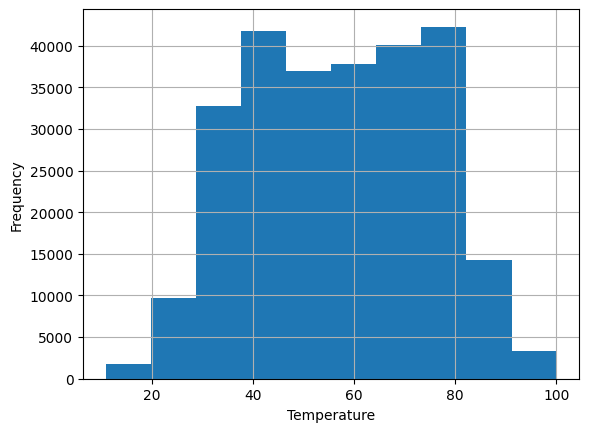

In [653]:
flights_train['temp'].hist()

plt.ylabel('Frequency')
plt.xlabel('Temperature')
plt.show()
# The distribution is roughly normal so we could use a median imputation
# strategy for missing values here

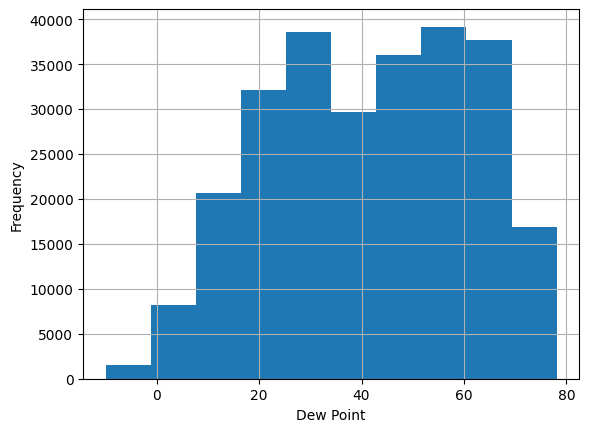

In [652]:
flights_train['dewp'].hist()

plt.ylabel('Frequency')
plt.xlabel('Dew Point')
plt.show()
# The distribution is roughly normal so we could use a median imputation
# strategy for missing values here

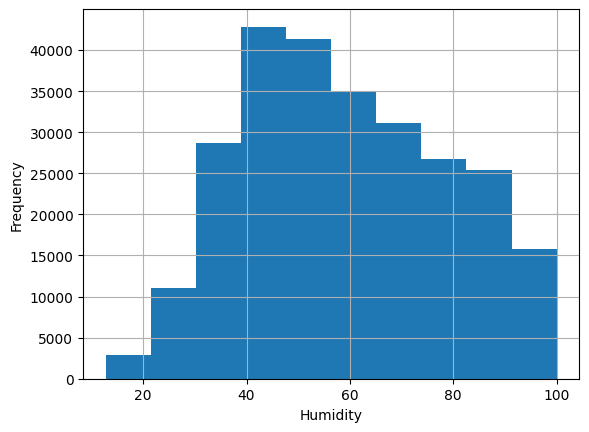

In [651]:
flights_train['humid'].hist()

plt.ylabel('Frequency')
plt.xlabel('Humidity')
plt.show()
# The distribution is roughly normal so we could use a median imputation
# strategy for missing values here

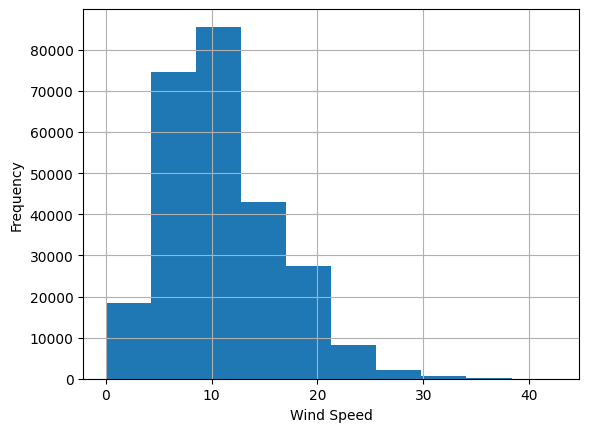

In [650]:
flights_train['wind_speed'].hist()

plt.ylabel('Frequency')
plt.xlabel('Wind Speed')
plt.show()
# The distribution is roughly normal but right skewed
# We will still use a median imputation strategy for missing values here
# Because the mean would be pulled up by the long tails on the left

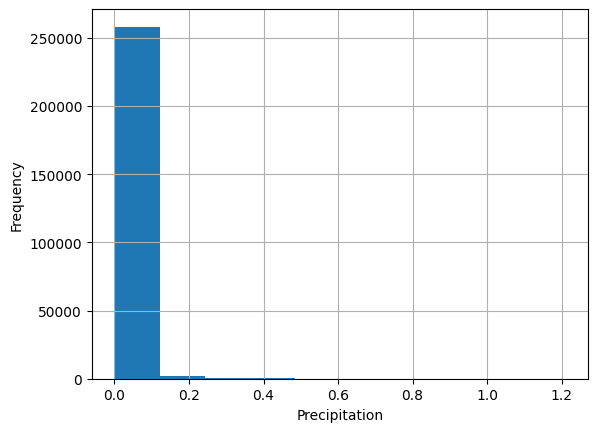

In [649]:
flights_train['precip'].hist()

plt.ylabel('Frequency')
plt.xlabel('Precipitation')
plt.show()
# Missing values should probably be filled in with the mode (0)
# Due to shape of distribution (one very long tail)

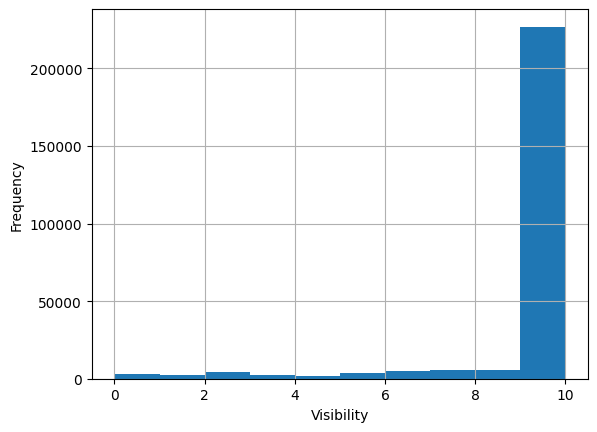

In [648]:
flights_train['visib'].hist()

plt.ylabel('Frequency')
plt.xlabel('Visibility')
plt.show()
# Missing values should probably be filled in with the mode (10)
# Due to shape of distribution (one very long tail)

Mean distance: 1048.2932532954528
Median distance: 888.0


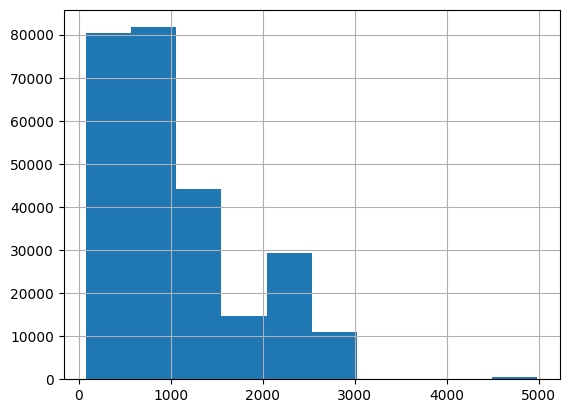

In [626]:
flights_train['distance'].hist()
# This distribution is heavily right skewed with long tails
# We will also use a median imputation strategy for missing values here
# Since the mean would be pulled up by the long tails

mean_distance = flights_train['distance'].mean()
median_distance = flights_train['distance'].median()

print(f"Mean distance: {mean_distance}"
      f"\nMedian distance: {median_distance}")

Categorical features to look at are:
* origin
* dest
* carrier / name
* month
* hour

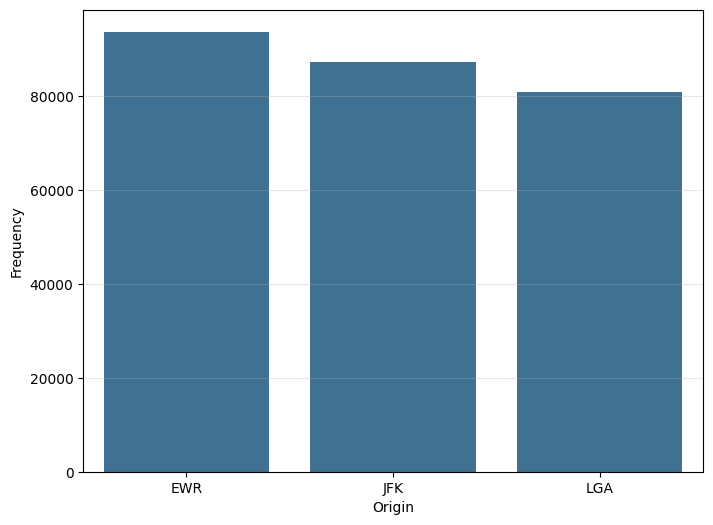

In [642]:
# Using a countplot instead of .hist() to align bars over categories clearly
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train, x='origin', color='#3274a1')

plt.ylabel('Frequency')
plt.xlabel('Origin')
plt.grid(axis='y', alpha=0.3)
plt.show()

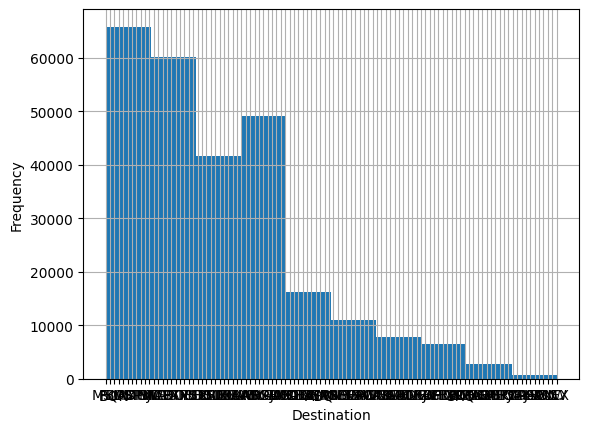

In [644]:
flights_train['dest'].hist()

plt.ylabel('Frequency')
plt.xlabel('Destination')
plt.show()

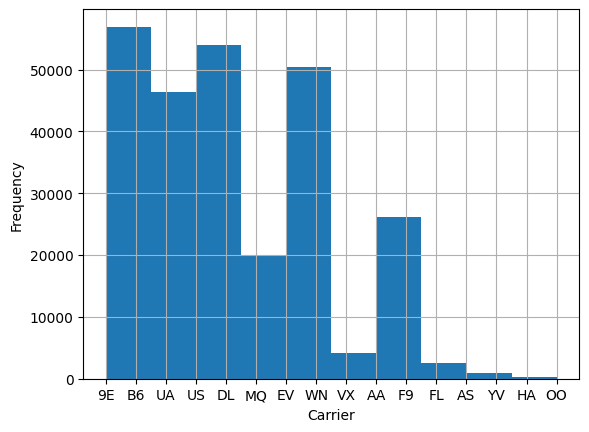

In [645]:
flights_train['carrier'].hist()

plt.ylabel('Frequency')
plt.xlabel('Carrier')
plt.show()

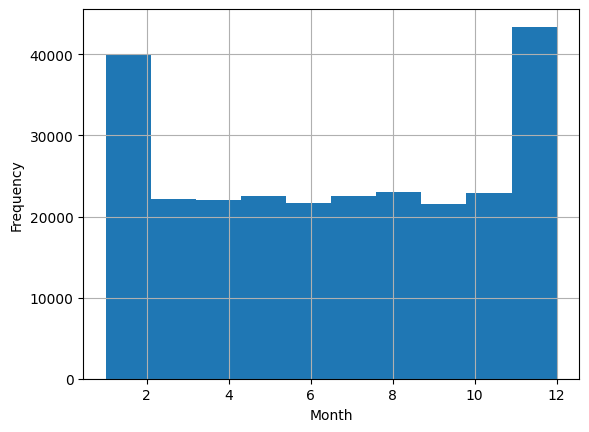

In [646]:
flights_train['month'].hist()

plt.ylabel('Frequency')
plt.xlabel('Month')
plt.show()

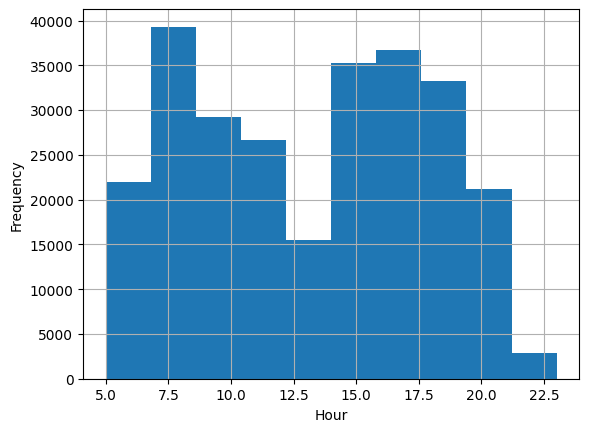

In [647]:
flights_train['hour'].hist()

plt.ylabel('Frequency')
plt.xlabel('Hour')
plt.show()